In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from vivarium import Artifact

!date

Wed May 27 15:33:39 PDT 2026


In [2]:
!ls -halt singapore.hdf # expects this to be in root directory of repo

-rw-r--r-- 1 abie Domain Users 35M May 20 15:44 singapore.hdf


In [3]:
# %run src/vivarium_csu_alzheimers/data/consistent_rates.py

In [4]:
art = Artifact(path='singapore.hdf')

In [5]:
# Build the SUSCEPTIBLE_TO_BBBM_TRANSITION_COUNT from the BBBM->AD incidence
# rate and the time-varying population (mirrors
# generate_consistent_data_for_population_components in
# src/vivarium_csu_alzheimers/data/consistent_rates.py). The old
# `population_incidence_any` key has been replaced by
# `susceptible_to_bbbm_ad_transition_rate`, and we now also multiply by
# (1 - prevalence) so the rate applies to the susceptible population only.

pop = art.load('population.structure')
transition_rate = art.load('cause.alzheimers_consistent.susceptible_to_bbbm_ad_transition_rate')
prevalence = art.load('cause.alzheimers_consistent.alzheimers_prevalence')

df = pd.merge(pop.reset_index().drop(['location'], axis=1),
              transition_rate.reset_index().drop(['year_start', 'year_end'], axis=1),
              on=['sex', 'age_start', 'age_end'],
              suffixes=('', '_rate'),
              ).set_index(['sex', 'age_start', 'age_end', 'year_start', 'year_end'])
df = pd.merge(df.reset_index(),
              prevalence.reset_index().drop(['year_start', 'year_end'], axis=1),
              on=['sex', 'age_start', 'age_end'],
              suffixes=('', '_prev'),
              ).set_index(['sex', 'age_start', 'age_end', 'year_start', 'year_end'])

for i in range(500):
    df[f'draw_{i}'] *= df[f'draw_{i}_rate'] * (1 - df[f'draw_{i}_prev'])
    del df[f'draw_{i}_rate']
    del df[f'draw_{i}_prev']

df

draw_0      draw_1  \
sex    age_start age_end year_start year_end                           
Female 30.0      35.0    2021       2022       20.622727    9.455848   
                         2022       2023       20.323398    9.300672   
                         2023       2024       19.949171    9.086769   
                         2024       2025       19.443995    8.834832   
                         2025       2026       18.847057    8.556630   
...                                                  ...         ...   
Male   90.0      95.0    2046       2047      579.144557  668.951615   
                         2047       2048      607.642082  704.589121   
                         2048       2049      638.606790  741.759759   
                         2049       2050      668.519390  778.609248   
                         2050       2051      694.641019  812.407763   

                                                  draw_2      draw_3  \
sex    age_start age_end year_start year_end                           
Female 30.0      35.0    2021       2022        8.897242   20.262161   
                         2022       2023        8.744340   19.935185   
                         2023       2024        8.539719   19.497367   
                         2024       2025        8.314136   18.972826   
                         2025       2026        8.074901   18.337406   
...                                                  ...         ...   
Male   90.0      95.0    2046       2047      646.209098  701.138469   
                         2047       2048      680.828502  736.628656   
                         2048       2049      717.837297  772.786927   
                         2049       2050      753.111187  807.466988   
                         2050       2051      785.254588  839.377226   

                                                  draw_4      draw_5  \
sex    age_start age_end year_start year_end                           
Female 30.0      35.0    2021       2022       19.700100   21.044076   
                         2022       2023       19.391950   20.667019   
                         2023       2024       18.996950   20.222763   
                         2024       2025       18.523583   19.751697   
                         2025       2026       17.990111   19.129227   
...                                                  ...         ...   
Male   90.0      95.0    2046       2047      622.982739  639.328221   
                         2047       2048      652.761748  669.803104   
                         2048       2049      684.491478  701.924666   
                         2049       2050      716.411037  733.154302   
                         2050       2051      746.544842  762.326463   

                                                  draw_6      draw_7  \
sex    age_start age_end year_start year_end                           
Female 30.0      35.0    2021       2022       10.131672    8.954219   
                         2022       2023        9.984911    8.781333   
                         2023       2024        9.805083    8.589995   
                         2024       2025        9.577498    8.370879   
                         2025       2026        9.282092    8.071768   
...                                                  ...         ...   
Male   90.0      95.0    2046       2047      576.310625  625.907937   
                         2047       2048      604.441519  656.936558   
                         2048       2049      636.542845  689.595730   
                         2049       2050      668.085059  722.704720   
                         2050       2051      695.932605  755.494702   

                                                  draw_8      draw_9  ...  \
sex    age_start age_end year_start year_end                          ...   
Female 30.0      35.0    2021       2022       14.538707   14.027845  ...   
                         2022       2023       14.291508   13.787238  .

In [6]:
# write_or_replace(art, 'cause.alzheimers_consistent.susceptible_to_bbbm_transition_count', df)

In [7]:
def data_etl(data):
    values = data.to_numpy()
    summary = pd.concat(
        [data.index.to_frame(index=False),
         pd.DataFrame({'mean': values.mean(axis=1),
                       '2.5%': np.quantile(values, 0.025, axis=1),
                       '97.5%': np.quantile(values, 0.975, axis=1)})],
        axis=1,
    )
    return summary[summary.age_end <= 95]

def art_etl(key):
    return data_etl(art.load(key))

In [8]:
def age_group_plot(measure, art_old, art_new):
    fig, ax = plt.subplots(ncols=2, sharex=True, sharey=True)
    for j, sex in enumerate(art_new.sex.unique()):
        for i, art_data in enumerate([art_old, art_new]):
            color = f'C{i}'
            if i == 0:
                linestyle = '--'
                label='Old'
            else:
                linestyle = '-'
                label='New'

            art_plot = art_data.loc[(art_data.sex == sex)]# & (art_data.year_start == art_year)]

            ax[j].fill_between(art_plot.age_start, art_plot['2.5%'], art_plot['97.5%'], alpha=0.2, color=color)
            ax[j].plot(art_plot.age_start, art_plot['mean'], linestyle=linestyle, label=label, color=color, linewidth=3)


        ax[j].text(.5, .95, f"{sex}", va='top', ha='center', transform=ax[j].transAxes)
        ax[j].set_xlabel("Age (years)")

        if j == 0:
            ax[j].set_ylabel(f"{measure}")
        if j == 1:
            ax[j].legend(loc=(1.01, 0))

        plt.subplots_adjust(wspace=0)

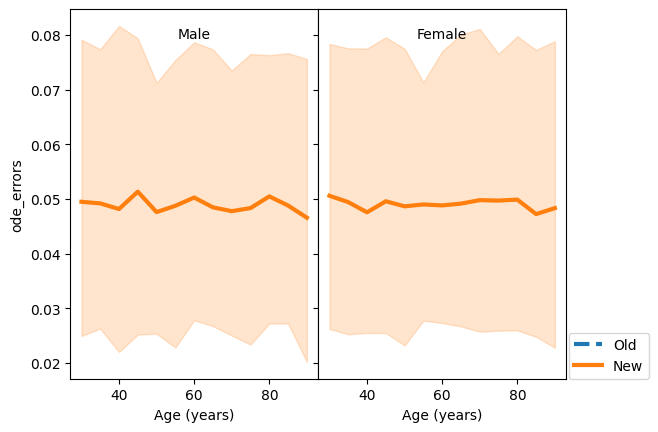

In [9]:
df_new = art_etl('cause.alzheimers_consistent.ode_errors')
df_old = df_new.iloc[[], :]
age_group_plot('ode_errors', df_old, df_new)

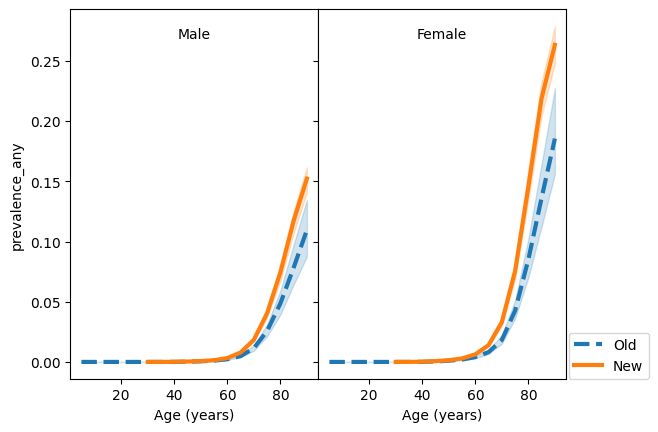

In [10]:
# Old artifacts stored a single `cause.alzheimers.prevalence`; the refactor
# split it into `ad_dementia_prevalence` + `mixed_dementia_prevalence`. Sum
# the two for an apples-to-apples comparison against the new consistent
# `alzheimers_prevalence` (all AD-attributable states: BBBM, MCI, dementia).
df_old = data_etl(art.load('cause.alzheimers.ad_dementia_prevalence')
                  + art.load('cause.alzheimers.mixed_dementia_prevalence'))
df_new = art_etl('cause.alzheimers_consistent.alzheimers_prevalence')
age_group_plot('prevalence_any', df_old, df_new)

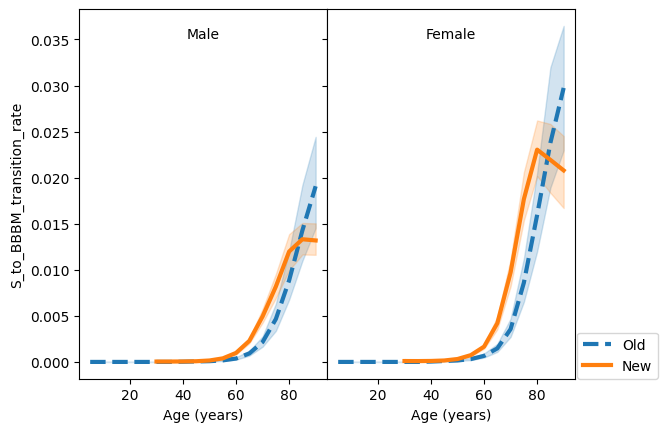

In [11]:
# Compare the GBD AD-dementia incidence (old) against the consistent
# S->BBBM transition rate (new). The latter replaces `population_incidence_any`.
df_old = data_etl(art.load('cause.alzheimers.ad_dementia_population_incidence_rate')
                  + art.load('cause.alzheimers.mixed_dementia_population_incidence_rate'))
df_new = art_etl('cause.alzheimers_consistent.susceptible_to_bbbm_ad_transition_rate')
age_group_plot('S_to_BBBM_transition_rate', df_old, df_new)

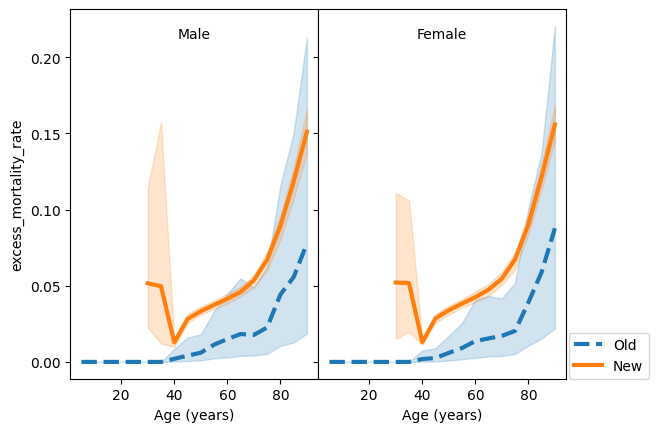

In [12]:
# The single `cause.alzheimers_consistent.excess_mortality_rate` was split
# into per-severity keys. Reconstruct a dementia-conditional EMR by
# delta-weighting the three severities (renormalizing by the dementia
# share, since BBBM/MCI states carry no EMR).
emr_mild = art.load('cause.alzheimers_consistent.excess_mortality_rate_mild')
emr_moderate = art.load('cause.alzheimers_consistent.excess_mortality_rate_moderate')
emr_severe = art.load('cause.alzheimers_consistent.excess_mortality_rate_severe')
delta_mild = art.load('cause.alzheimers_consistent.mild_dementia_conditional_prevalence')
delta_moderate = art.load('cause.alzheimers_consistent.moderate_dementia_conditional_prevalence')
delta_severe = art.load('cause.alzheimers_consistent.severe_dementia_conditional_prevalence')

dementia_share = delta_mild + delta_moderate + delta_severe
emr_dementia = (emr_mild * delta_mild
                + emr_moderate * delta_moderate
                + emr_severe * delta_severe) / dementia_share

df_old = art_etl('cause.alzheimers_disease_and_other_dementias.excess_mortality_rate')
df_new = data_etl(emr_dementia)
age_group_plot('excess_mortality_rate', df_old, df_new)

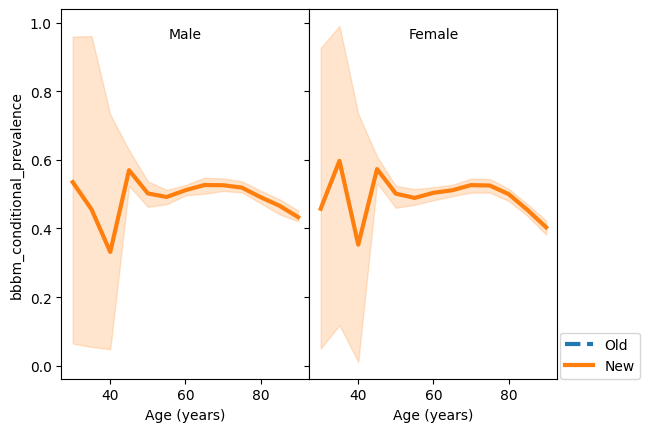

In [13]:
# GBD has no pre-AD biomarker prevalence, so there is no "old" curve to
# compare against; only plot the consistent-model output.
df_new = art_etl('cause.alzheimers_consistent.bbbm_conditional_prevalence')
df_old = df_new.iloc[[], :]
age_group_plot('bbbm_conditional_prevalence', df_old, df_new)

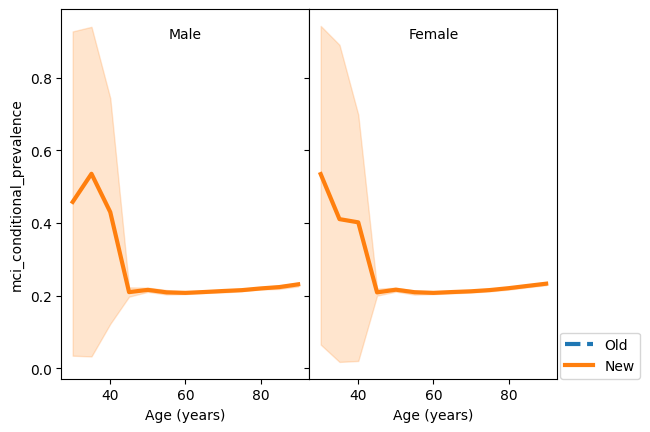

In [14]:
# GBD has no MCI prevalence either; only plot the consistent-model output.
df_new = art_etl('cause.alzheimers_consistent.mci_conditional_prevalence')
df_old = df_new.iloc[[], :]
age_group_plot('mci_conditional_prevalence', df_old, df_new)

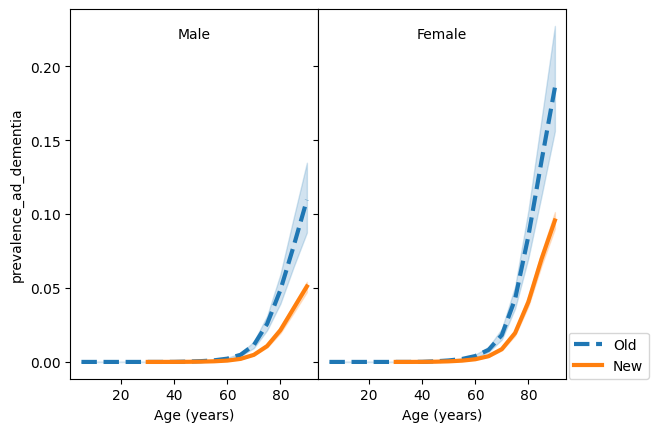

In [15]:
# Convert the consistent total-AD prevalence into AD-dementia-only prevalence
# by multiplying by (1 - bbbm - mci), i.e. the dementia-phase share.
df_old = data_etl(art.load('cause.alzheimers.ad_dementia_prevalence')
                  + art.load('cause.alzheimers.mixed_dementia_prevalence'))
df_new = art_etl('cause.alzheimers_consistent.alzheimers_prevalence')

dementia_conditional_prevalence = (1 -
(
    art_etl('cause.alzheimers_consistent.bbbm_conditional_prevalence')['mean'].values
    + art_etl('cause.alzheimers_consistent.mci_conditional_prevalence')['mean'].values
))
df_new['mean'] *= dementia_conditional_prevalence
df_new['2.5%'] *= dementia_conditional_prevalence
df_new['97.5%'] *= dementia_conditional_prevalence

age_group_plot('prevalence_ad_dementia', df_old, df_new)

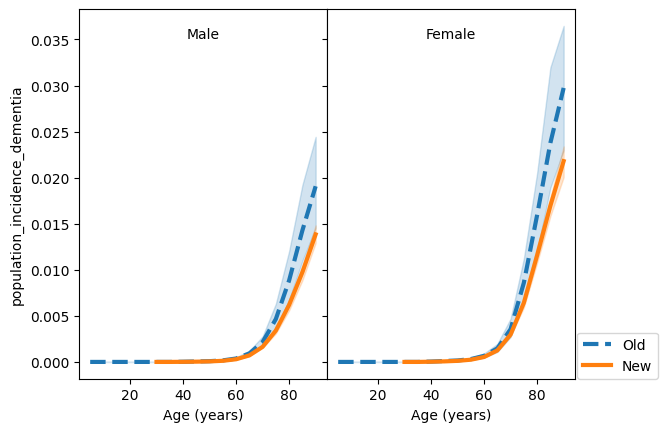

In [16]:
# Compare GBD AD-dementia incidence against the consistent incidence into
# mild dementia (replaces the old `population_incidence_dementia` key).
df_old = data_etl(art.load('cause.alzheimers.ad_dementia_population_incidence_rate')
                  + art.load('cause.alzheimers.mixed_dementia_population_incidence_rate'))
df_new = art_etl('cause.alzheimers_consistent.population_incidence_mild_dementia')
age_group_plot('population_incidence_dementia', df_old, df_new)

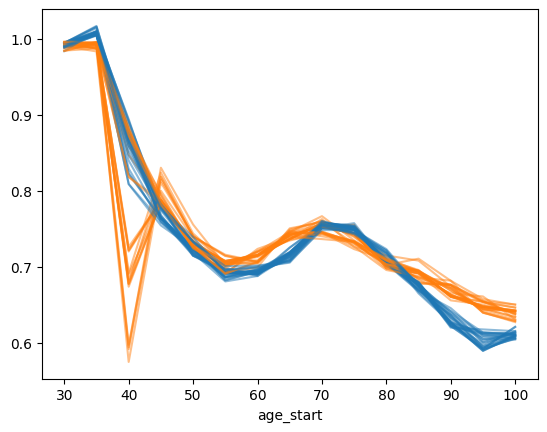

In [17]:
t = art.load('cause.alzheimers_consistent.bbbm_conditional_prevalence') + art.load('cause.alzheimers_consistent.mci_conditional_prevalence')
for col in t.filter(like='draw_').columns[:25]:
    t[col].unstack(level=0).reset_index().set_index('age_start').Male.plot(color='C1', alpha=.5)
    t[col].unstack(level=0).reset_index().set_index('age_start').Female.plot(color='C0', alpha=.5)